# Real Fashion Dataset - Complete Pipeline

#### STEP 1: IMPORT LIBRARIES

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import decode_predictions
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import Xception
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from datetime import datetime
from pathlib import Path


# Set style and seeds
sns.set_style("whitegrid")
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


#### STEP 2: DATASET SETUP & DOWNLOAD

In [ ]:
!unzip /content/data.zip

In [3]:
# Load the CSV file
df = pd.read_csv('/content/data/styles.csv', on_bad_lines='skip')

print(f"\n✅ Loaded styles.csv")
print(f"   Total entries: {len(df):,}")
print(f"\n📋 Dataset Info:")
print(df.info())

print(f"\n📊 First few rows:")
print(df.head(10))

print(f"\n🔍 Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

# Check for missing values
print(f"\n⚠️  Missing Values:")
print(df.isnull().sum())


✅ Loaded styles.csv
   Total entries: 44,424

📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  object 
 2   masterCategory      44424 non-null  object 
 3   subCategory         44424 non-null  object 
 4   articleType         44424 non-null  object 
 5   baseColour          44409 non-null  object 
 6   season              44403 non-null  object 
 7   year                44423 non-null  float64
 8   usage               44107 non-null  object 
 9   productDisplayName  44417 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.4+ MB
None

📊 First few rows:
      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall  

#### STEP 2: UNDERSTAND THE DATASET STRUCTURE

In [4]:
# Identify the key columns (adapt based on actual columns)
print("\n🔍 Analyzing key columns...")

# Common column variations
id_col = 'id' if 'id' in df.columns else df.columns[0]
article_col = None
for col_name in ['articleType', 'article_type', 'category', 'subCategory']:
    if col_name in df.columns:
        article_col = col_name
        break

if article_col is None:
    # Try to find a suitable column
    for col in df.columns:
        if 'type' in col.lower() or 'category' in col.lower():
            article_col = col
            break

print(f"\n📌 Key columns identified:")
print(f"   ID column: {id_col}")
print(f"   Category column: {article_col if article_col else 'NOT FOUND - will use first text column'}")

# If article column not found, use a text column
if article_col is None:
    for col in df.columns:
        if df[col].dtype == 'object' and col != id_col:
            article_col = col
            print(f"   Using '{col}' as category column")
            break


🔍 Analyzing key columns...

📌 Key columns identified:
   ID column: id
   Category column: articleType


#### STEP 3: DATA CLEANING AND PREPARATION

In [5]:
# Drop rows with missing critical values
df_clean = df.dropna(subset=[id_col, article_col])

print(f"\n🧹 Cleaning:")
print(f"   Original rows: {len(df):,}")
print(f"   After cleaning: {len(df_clean):,}")
print(f"   Removed: {len(df) - len(df_clean):,} rows")

# Analyze categories
print(f"\n📊 Category Distribution:")
category_counts = df_clean[article_col].value_counts()
print(f"   Total unique categories: {len(category_counts)}")
print(f"\n   Top 15 categories:")
print(category_counts.head(15))

# Select top N categories for classification
TOP_N_CATEGORIES = 15  # Adjust based on your needs
top_categories = category_counts.head(TOP_N_CATEGORIES).index.tolist()

# Filter dataset to top categories
df_filtered = df_clean[df_clean[article_col].isin(top_categories)].copy()

print(f"\n✂️  Filtered to top {TOP_N_CATEGORIES} categories:")
print(f"   Samples: {len(df_filtered):,}")
print(f"   Categories: {', '.join(top_categories[:5])}...")


🧹 Cleaning:
   Original rows: 44,424
   After cleaning: 44,424
   Removed: 0 rows

📊 Category Distribution:
   Total unique categories: 143

   Top 15 categories:
articleType
Tshirts         7067
Shirts          3217
Casual Shoes    2845
Watches         2542
Sports Shoes    2036
Kurtas          1844
Tops            1762
Handbags        1759
Heels           1323
Sunglasses      1073
Wallets          936
Flip Flops       914
Sandals          897
Briefs           849
Belts            813
Name: count, dtype: int64

✂️  Filtered to top 15 categories:
   Samples: 29,877
   Categories: Tshirts, Shirts, Casual Shoes, Watches, Sports Shoes...


#### STEP 4: VERIFY IMAGE FILES EXIST

In [6]:
# Typical structure: images folder with id.jpg or id.png
IMAGE_DIR = '/content/data/images'  # Default location

# Check if images directory exists
if not os.path.exists(IMAGE_DIR):
    print(f"\n⚠️  Image directory '{IMAGE_DIR}' not found!")
    print("\nPlease ensure images are in one of these locations:")
    print("   • images/")
    print("   • data/images/")
    print("   • fashion_dataset/images/")
    print("   • /content/myntradataset/images/")
    print("\nOr update IMAGE_DIR variable in the code.")

    # Try alternative locations
    for alt_dir in ['data/images', 'fashion_dataset/images', './', '/content/myntradataset/images']:
        if os.path.exists(alt_dir):
            IMAGE_DIR = alt_dir
            print(f"\n✅ Found images in: {IMAGE_DIR}")
            break
else:
    print(f"✅ Image directory found: {IMAGE_DIR}")

# Check image availability
def image_exists(image_id):
    """Check if image file exists"""
    for ext in ['.jpg', '.png', '.jpeg']:
        path = os.path.join(IMAGE_DIR, f"{image_id}{ext}")
        if os.path.exists(path):
            return path
    return None

# Verify images exist
print("\n🔍 Checking image availability...")
df_filtered['image_path'] = df_filtered[id_col].apply(image_exists)
df_with_images = df_filtered[df_filtered['image_path'].notna()].copy()

print(f"\n📊 Image Availability:")
print(f"   Expected images: {len(df_filtered):,}")
print(f"   Found images: {len(df_with_images):,}")
print(f"   Missing: {len(df_filtered) - len(df_with_images):,}")

if len(df_with_images) < 100:
    print("\n⚠️  WARNING: Very few images found!")
    print("Please check that:")
    print("   1. Images are extracted from the zip file")
    print("   2. IMAGE_DIR points to correct location")
    print("   3. Image filenames match the IDs in CSV")
    print("\nProceeding with available images for demonstration...")

# Use the filtered dataset
df_final = df_with_images.copy()

print(f"\n✅ Final dataset ready:")
print(f"   Total samples: {len(df_final):,}")
print(f"   Categories: {TOP_N_CATEGORIES}")

✅ Image directory found: /content/data/images

🔍 Checking image availability...

📊 Image Availability:
   Expected images: 29,877
   Found images: 29,874
   Missing: 3

✅ Final dataset ready:
   Total samples: 29,874
   Categories: 15


#### STEP 5: PREPARE TRAIN/VAL/TEST SPLITS

In [7]:
# Encode labels
label_encoder = LabelEncoder()
df_final['label'] = label_encoder.fit_transform(df_final[article_col])

# Get category names
category_names = label_encoder.classes_
print(f"\n📋 Categories ({len(category_names)}):")
for i, cat in enumerate(category_names):
    count = (df_final['label'] == i).sum()
    print(f"   {i}. {cat:30s} - {count:,} samples")

# Split dataset
X = df_final['image_path'].values
y = df_final['label'].values

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Second split: 80% train, 20% val (of the train+val set)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42
)

print(f"\n📊 Data Split:")
print(f"   Training:   {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Validation: {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test:       {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")


📋 Categories (15):
   0. Belts                          - 813 samples
   1. Briefs                         - 849 samples
   2. Casual Shoes                   - 2,845 samples
   3. Flip Flops                     - 914 samples
   4. Handbags                       - 1,759 samples
   5. Heels                          - 1,323 samples
   6. Kurtas                         - 1,844 samples
   7. Sandals                        - 897 samples
   8. Shirts                         - 3,215 samples
   9. Sports Shoes                   - 2,036 samples
   10. Sunglasses                     - 1,073 samples
   11. Tops                           - 1,762 samples
   12. Tshirts                        - 7,066 samples
   13. Wallets                        - 936 samples
   14. Watches                        - 2,542 samples

📊 Data Split:
   Training:   19,119 samples (64.0%)
   Validation: 4,780 samples (16.0%)
   Test:       5,975 samples (20.0%)


#### STEP 6: VISUALIZE SAMPLE IMAGES

STEP 6: VISUALIZING DATASET

🖼️  Loading sample images from each category...


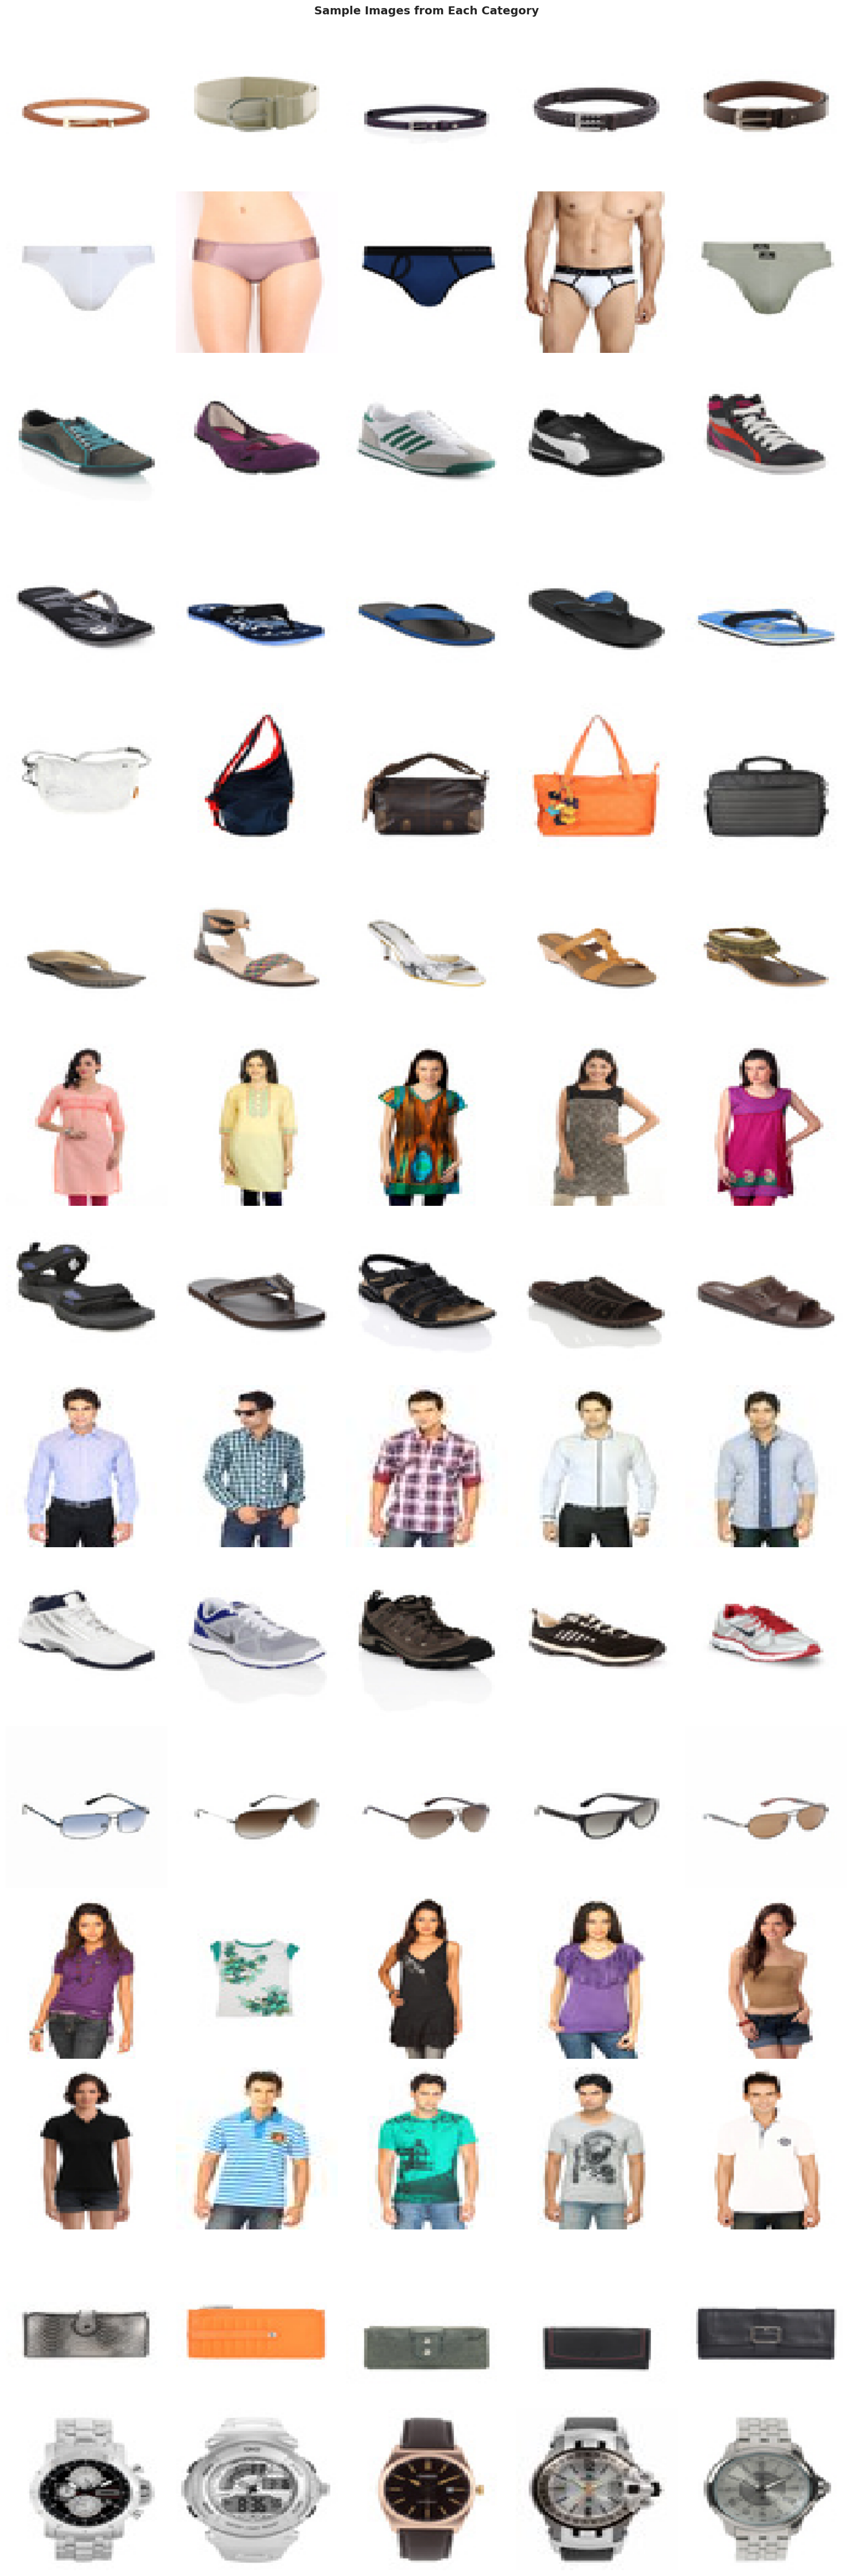

✅ Visualization saved: real_dataset_samples.png


In [8]:
print("STEP 6: VISUALIZING DATASET")

print("\n🖼️  Loading sample images from each category...")

fig, axes = plt.subplots(len(category_names), 5, figsize=(15, 3*len(category_names)))

if len(category_names) == 1:
    axes = axes.reshape(1, -1)

for cat_idx, category in enumerate(category_names):
    # Find samples for this category
    cat_paths = X_train[y_train == cat_idx][:5]

    for img_idx in range(5):
        if img_idx < len(cat_paths):
            try:
                img = load_img(cat_paths[img_idx], target_size=(150, 150))
                axes[cat_idx, img_idx].imshow(img)
            except Exception as e:
                axes[cat_idx, img_idx].text(0.5, 0.5, 'Error\nLoading',
                                           ha='center', va='center')

        if img_idx == 0:
            axes[cat_idx, img_idx].set_ylabel(category, fontsize=10, fontweight='bold')
        axes[cat_idx, img_idx].axis('off')

plt.suptitle('Sample Images from Each Category', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('real_dataset_samples.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization saved: real_dataset_samples.png")

#### STEP 7: CREATE CATEGORY FOLDER STRUCTURE


In [9]:
# Create directory structure for a real dataset
base_dir = 'fashion_dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

In [10]:
# Categories for our fashion dataset
category_names = [
    'Belts',
    'Briefs',
    'Casual Shoes',
    'Flip Flops',
    'Handbags',
    'Heels',
    'Kurtas',
    'Sandals',
    'Shirts',
    'Sports Shoes',
    'Sunglasses',
    'Tops',
    'Tshirts',
    'Wallets',
    'Watches'
    ]

In [11]:
print("\n📁 Creating dataset directory structure...")
for directory in [train_dir, val_dir, test_dir]:
    for category in category_names:
        category_dir = os.path.join(directory, category.replace(' ', '_'))
        os.makedirs(category_dir, exist_ok=True)


📁 Creating dataset directory structure...


#### STEP 8: MOVE IMAGES TO CATEGORY FOLDERS


In [12]:
import shutil

print("\n📦 Copying images to category folders...")

# Create sets for faster lookup of image paths in each split
train_paths_set = set(X_train)
val_paths_set = set(X_val)
test_paths_set = set(X_test)

def get_destination_dir(image_path, label_idx):
    """Determines the correct destination directory for an image."""
    category_folder_name = category_names[label_idx].replace(' ', '_')
    if image_path in train_paths_set:
        return os.path.join(train_dir, category_folder_name)
    elif image_path in val_paths_set:
        return os.path.join(val_dir, category_folder_name)
    elif image_path in test_paths_set:
        return os.path.join(test_dir, category_folder_name)
    else:
        return None

# Iterate through the final dataset (which contains all image paths and labels)
copied_count = 0
for idx, row in df_final.iterrows():
    source_path = row['image_path']
    label_idx = row['label']

    dest_dir = get_destination_dir(source_path, label_idx)

    if dest_dir and os.path.exists(source_path):
        os.makedirs(dest_dir, exist_ok=True) # Ensure destination folder exists
        dest_path = os.path.join(dest_dir, os.path.basename(source_path))
        try:
            shutil.copyfile(source_path, dest_path)
            copied_count += 1
        except Exception as e:
            print(f"Error copying {source_path} to {dest_path}: {e}")
    else:
        # This case should ideally not happen if df_final contains only existing image paths
        print(f"Skipping {source_path}: destination directory not found or source path invalid.")

print(f"\n✅ Finished copying {copied_count:,} images to respective category folders.")


📦 Copying images to category folders...

✅ Finished copying 29,874 images to respective category folders.


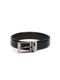

In [13]:
path = '/content/fashion_dataset/train/Belts'
name = '10331.jpg'
fullname = f'{path}/{name}'
load_img(fullname)

In [14]:
img = load_img(fullname, target_size=(299, 299))

In [15]:
model = Xception(
    weights='imagenet',
    input_shape=(299, 299, 3)
)

91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [16]:
x = img_to_array(img)
x.shape

(299, 299, 3)

In [17]:
#X = np.array([x])
X = np.expand_dims(x, axis=0)
X.shape

(1, 299, 299, 3)

In [18]:
X = preprocess_input(X)
X[0]

array([[[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       ...,

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]]], dtype=float32)

In [19]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step


In [20]:
pred.shape

(1, 1000)

In [21]:
pred

array([[1.75670400e-04, 1.93632688e-04, 2.13446081e-04, 3.28315742e-04,
        5.27497730e-04, 2.36969106e-04, 1.81106399e-04, 1.98508438e-04,
        1.07017433e-04, 9.73738715e-05, 2.84836831e-04, 3.11102747e-04,
        1.56819529e-04, 1.73330380e-04, 1.14743983e-04, 1.68039798e-04,
        9.30166643e-05, 1.27744832e-04, 1.48921987e-04, 2.65987008e-04,
        8.81653614e-05, 2.96281622e-04, 1.14874492e-04, 2.79704516e-04,
        3.51950352e-04, 3.31781019e-04, 1.55541566e-04, 2.32563863e-04,
        3.66876047e-04, 1.60153577e-04, 1.55876885e-04, 2.01941119e-04,
        1.42403413e-04, 2.25299969e-04, 4.34828893e-04, 2.10404411e-04,
        6.68421781e-05, 1.38851668e-04, 3.29058967e-04, 2.63625901e-04,
        1.46550985e-04, 1.32026689e-04, 4.55150148e-04, 1.86795209e-04,
        1.01452359e-04, 2.44460301e-04, 1.48470921e-04, 1.02904312e-04,
        2.11126506e-04, 1.93789732e-04, 1.41761673e-04, 1.38420262e-04,
        3.00005311e-04, 4.12001507e-04, 2.17213616e-04, 2.448212

In [22]:
pred[0]

array([1.75670400e-04, 1.93632688e-04, 2.13446081e-04, 3.28315742e-04,
       5.27497730e-04, 2.36969106e-04, 1.81106399e-04, 1.98508438e-04,
       1.07017433e-04, 9.73738715e-05, 2.84836831e-04, 3.11102747e-04,
       1.56819529e-04, 1.73330380e-04, 1.14743983e-04, 1.68039798e-04,
       9.30166643e-05, 1.27744832e-04, 1.48921987e-04, 2.65987008e-04,
       8.81653614e-05, 2.96281622e-04, 1.14874492e-04, 2.79704516e-04,
       3.51950352e-04, 3.31781019e-04, 1.55541566e-04, 2.32563863e-04,
       3.66876047e-04, 1.60153577e-04, 1.55876885e-04, 2.01941119e-04,
       1.42403413e-04, 2.25299969e-04, 4.34828893e-04, 2.10404411e-04,
       6.68421781e-05, 1.38851668e-04, 3.29058967e-04, 2.63625901e-04,
       1.46550985e-04, 1.32026689e-04, 4.55150148e-04, 1.86795209e-04,
       1.01452359e-04, 2.44460301e-04, 1.48470921e-04, 1.02904312e-04,
       2.11126506e-04, 1.93789732e-04, 1.41761673e-04, 1.38420262e-04,
       3.00005311e-04, 4.12001507e-04, 2.17213616e-04, 2.44821247e-04,
      

In [23]:
decode_predictions(pred)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[[('n03314780', 'face_powder', np.float32(0.14883094)),
  ('n03062245', 'cocktail_shaker', np.float32(0.08798482)),
  ('n03400231', 'frying_pan', np.float32(0.055037577)),
  ('n04542943', 'waffle_iron', np.float32(0.047274828)),
  ('n04254120', 'soap_dispenser', np.float32(0.045827787))]]

#### STEP 9: CREATE DATA GENERATORS

In [24]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory(
    '/content/fashion_dataset/train',
    target_size=(150, 150),
    batch_size=32
)

Found 19119 images belonging to 15 classes.


In [25]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    '/content/fashion_dataset/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 4780 images belonging to 15 classes.


In [26]:
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = test_gen.flow_from_directory(
    '/content/fashion_dataset/test',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 5975 images belonging to 15 classes.


#### STEP 10: PRETRAIN MODEL

In [27]:
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

base_model.trainable = False
inputs = keras.Input(shape=(150, 150, 3))
base = base_model(inputs, training=False)
vectors = keras.layers.GlobalAveragePooling2D()(base)
outputs = keras.layers.Dense(15)(vectors)
model = keras.Model(inputs, outputs)


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [28]:
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

loss = keras.losses.CategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [29]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 81s 106ms/step - accuracy: 0.7840 - loss: 0.7896 - val_accuracy: 0.8469 - val_loss: 0.6852
Epoch 2/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 40s 66ms/step - accuracy: 0.8809 - loss: 0.4415 - val_accuracy: 0.8494 - val_loss: 0.6835
Epoch 3/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 40s 68ms/step - accuracy: 0.8954 - loss: 0.3760 - val_accuracy: 0.8477 - val_loss: 0.8211
Epoch 4/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 42s 70ms/step - accuracy: 0.9135 - loss: 0.3128 - val_accuracy: 0.8542 - val_loss: 0.8153
Epoch 5/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.9132 - loss: 0.3131 - val_accuracy: 0.8724 - val_loss: 0.6753
Epoch 6/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 71ms/step - accuracy: 0.9202 - loss: 0.2847 - val_accuracy: 0.8674 - val_loss: 0.7779
Epoch 7/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 71ms/step - accuracy: 0.9312 - loss: 0.2444 - val_accuracy: 0.8646 - val_loss: 0.8731
Epoch 8/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 71ms/step - accuracy: 0.9380 - loss: 0.2194 -

In [30]:
history.history['accuracy']

[0.822637140750885,
 0.8741043210029602,
 0.8921491503715515,
 0.9095140695571899,
 0.907840371131897,
 0.9144829511642456,
 0.9263559579849243,
 0.9322140216827393,
 0.9298603534698486,
 0.9352476596832275]

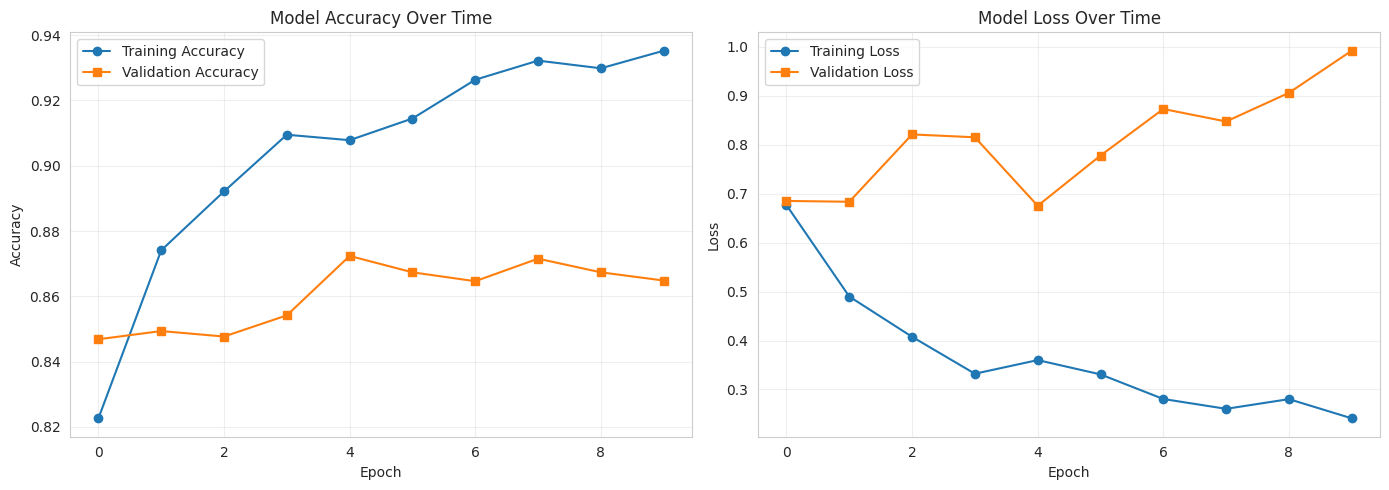

In [31]:
# Plot training & validation accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], marker='o', label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], marker='s', label='Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], marker='o', label='Training Loss')
ax2.plot(history.history['val_loss'], marker='s', label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Model Loss Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
def make_model(learning_rate=0.01):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    outputs = keras.layers.Dense(15)(vectors)
    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

#### STEP 11: CHECKPOINTING
- SAVE THE BEST MODEL WITH LEARNING RATE 0.001

In [33]:
# Create directories
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('logs', exist_ok=True)

callbacks_list = [
    keras.callbacks.ModelCheckpoint(
        'checkpoints/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.CSVLogger('logs/training_history.csv'),
]

In [34]:
learning_rate = 0.001

model = make_model(learning_rate=learning_rate)

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=callbacks_list
)

Epoch 1/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7532 - loss: 0.7447
Epoch 1: val_accuracy improved from -inf to 0.86088, saving model to checkpoints/best_model.keras
598/598 ━━━━━━━━━━━━━━━━━━━━ 62s 91ms/step - accuracy: 0.7534 - loss: 0.7443 - val_accuracy: 0.8609 - val_loss: 0.3852 - learning_rate: 0.0010
Epoch 2/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8855 - loss: 0.3159
Epoch 2: val_accuracy improved from 0.86088 to 0.87238, saving model to checkpoints/best_model.keras
598/598 ━━━━━━━━━━━━━━━━━━━━ 67s 74ms/step - accuracy: 0.8855 - loss: 0.3159 - val_accuracy: 0.8724 - val_loss: 0.3530 - learning_rate: 0.0010
Epoch 3/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9007 - loss: 0.2739
Epoch 3: val_accuracy improved from 0.87238 to 0.87741, saving model to checkpoints/best_model.keras
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.9007 - loss: 0.2739 - val_accuracy: 0.8774 - val_loss: 0.3320 - learning_rate: 0.0010
Epoch 4/10

#### STEP 12: ADDING ONE INNER DENSE LAYER OF SIZE 100

In [35]:
def make_model(learning_rate=0.01, size_inner=100):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)

    outputs = keras.layers.Dense(15)(inner)

    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [36]:
learning_rate = 0.001
size = 100

model = make_model(
    learning_rate=learning_rate,
    size_inner=size
)

history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.7762 - loss: 0.6547 - val_accuracy: 0.8659 - val_loss: 0.3676
Epoch 2/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 42s 71ms/step - accuracy: 0.8914 - loss: 0.2898 - val_accuracy: 0.8519 - val_loss: 0.3971
Epoch 3/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 71ms/step - accuracy: 0.9132 - loss: 0.2308 - val_accuracy: 0.8818 - val_loss: 0.3256
Epoch 4/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 71ms/step - accuracy: 0.9237 - loss: 0.2041 - val_accuracy: 0.8762 - val_loss: 0.3414
Epoch 5/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 83s 73ms/step - accuracy: 0.9385 - loss: 0.1727 - val_accuracy: 0.8759 - val_loss: 0.3646
Epoch 6/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 42s 70ms/step - accuracy: 0.9496 - loss: 0.1378 - val_accuracy: 0.8856 - val_loss: 0.3398
Epoch 7/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.9469 - loss: 0.1313 - val_accuracy: 0.8795 - val_loss: 0.3697
Epoch 8/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 71ms/step - accuracy: 0.9565 - loss: 0.1123 - 

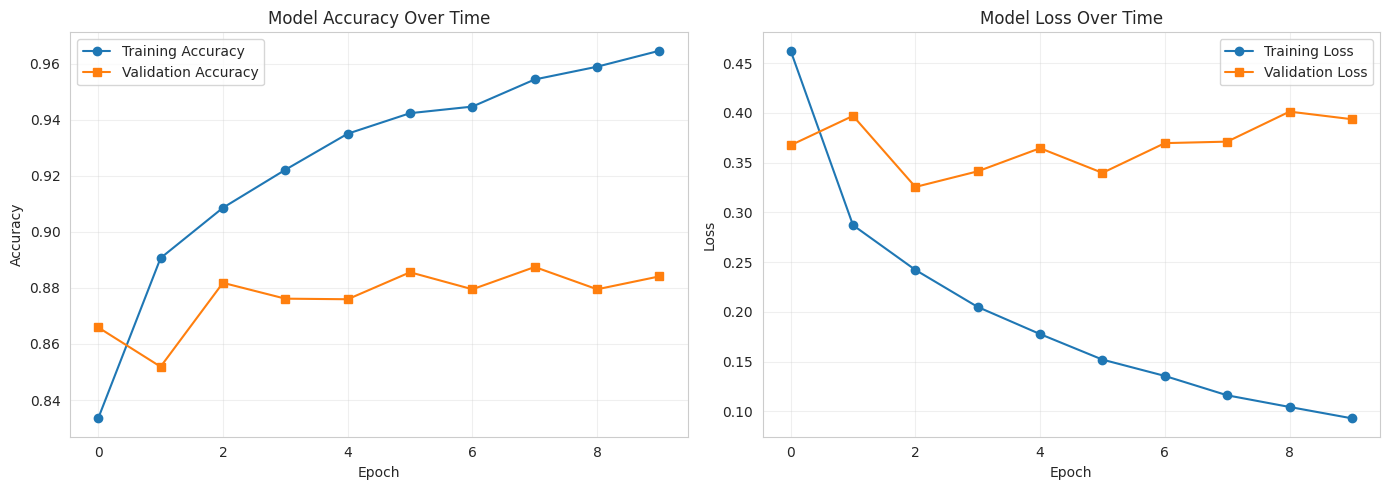

In [37]:
# Plot training & validation accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], marker='o', label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], marker='s', label='Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], marker='o', label='Training Loss')
ax2.plot(history.history['val_loss'], marker='s', label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Model Loss Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### STEP 13: REGULARIZATION AND DROPOUT 0.2

In [38]:
def make_model(learning_rate=0.01, size_inner=100, droprate=0.5):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)

    outputs = keras.layers.Dense(15)(drop)

    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [39]:
learning_rate = 0.001
size = 100
droprate = 0.2

model = make_model(
      learning_rate=learning_rate,
      size_inner=size,
      droprate=droprate
)

history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 64s 93ms/step - accuracy: 0.7543 - loss: 0.7183 - val_accuracy: 0.8617 - val_loss: 0.3653
Epoch 2/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.8800 - loss: 0.3248 - val_accuracy: 0.8646 - val_loss: 0.3471
Epoch 3/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.8939 - loss: 0.2769 - val_accuracy: 0.8732 - val_loss: 0.3425
Epoch 4/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.9066 - loss: 0.2341 - val_accuracy: 0.8738 - val_loss: 0.3344
Epoch 5/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.9204 - loss: 0.2121 - val_accuracy: 0.8897 - val_loss: 0.3040
Epoch 6/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 71ms/step - accuracy: 0.9315 - loss: 0.1799 - val_accuracy: 0.8885 - val_loss: 0.3086
Epoch 7/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.9325 - loss: 0.1699 - val_accuracy: 0.8812 - val_loss: 0.3280
Epoch 8/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 71ms/step - accuracy: 0.9422 - loss: 0.1538 - 

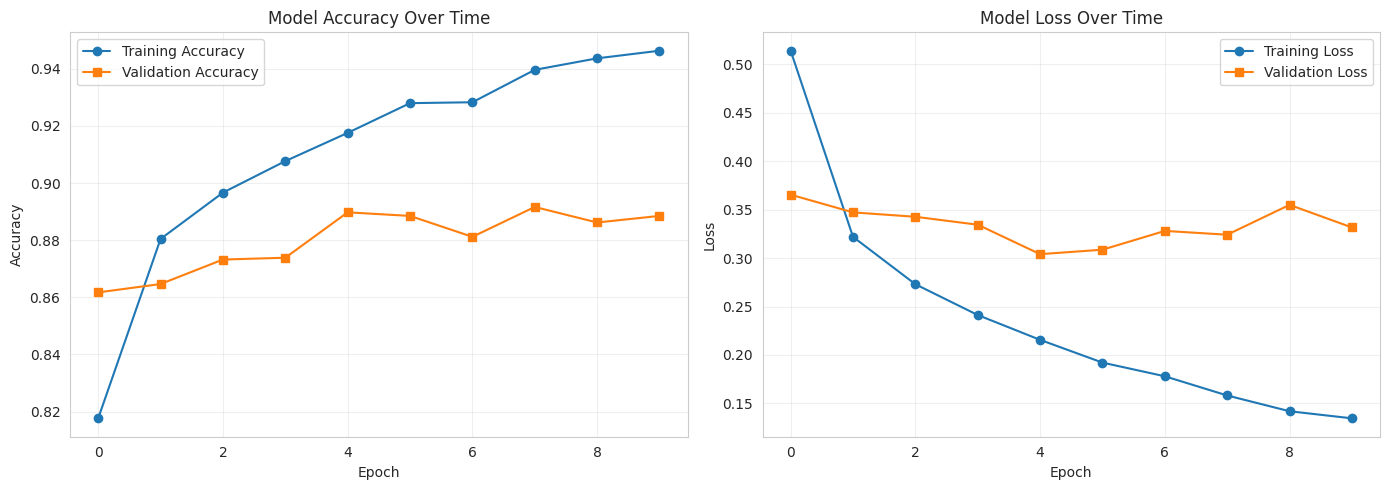

In [40]:
# Plot training & validation accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], marker='o', label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], marker='s', label='Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], marker='o', label='Training Loss')
ax2.plot(history.history['val_loss'], marker='s', label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Model Loss Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### STEP 14: TRAINING A MODEL WITH AUGMENTATIONS

In [41]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10,
    zoom_range=0.1,
    vertical_flip=True,
)

train_ds = train_gen.flow_from_directory(
    '/content/fashion_dataset/train',
    target_size=(150, 150),
    batch_size=32
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    '/content/fashion_dataset/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = test_gen.flow_from_directory(
    '/content/fashion_dataset/test',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 19119 images belonging to 15 classes.
Found 4780 images belonging to 15 classes.
Found 5975 images belonging to 15 classes.


In [42]:
learning_rate = 0.001
size = 100
droprate = 0.2

model = make_model(
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

history = model.fit(train_ds, epochs=10, validation_data=val_ds)


Epoch 1/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 143s 224ms/step - accuracy: 0.7048 - loss: 0.8930 - val_accuracy: 0.8429 - val_loss: 0.4231
Epoch 2/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 122s 204ms/step - accuracy: 0.8372 - loss: 0.4462 - val_accuracy: 0.8592 - val_loss: 0.3815
Epoch 3/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 122s 204ms/step - accuracy: 0.8574 - loss: 0.3948 - val_accuracy: 0.8649 - val_loss: 0.3568
Epoch 4/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 123s 205ms/step - accuracy: 0.8609 - loss: 0.3702 - val_accuracy: 0.8703 - val_loss: 0.3530
Epoch 5/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 122s 204ms/step - accuracy: 0.8658 - loss: 0.3596 - val_accuracy: 0.8720 - val_loss: 0.3332
Epoch 6/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 122s 205ms/step - accuracy: 0.8732 - loss: 0.3376 - val_accuracy: 0.8724 - val_loss: 0.3455
Epoch 7/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 125s 208ms/step - accuracy: 0.8770 - loss: 0.3214 - val_accuracy: 0.8778 - val_loss: 0.3234
Epoch 8/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 121s 202ms/step - accuracy: 0.8870 -

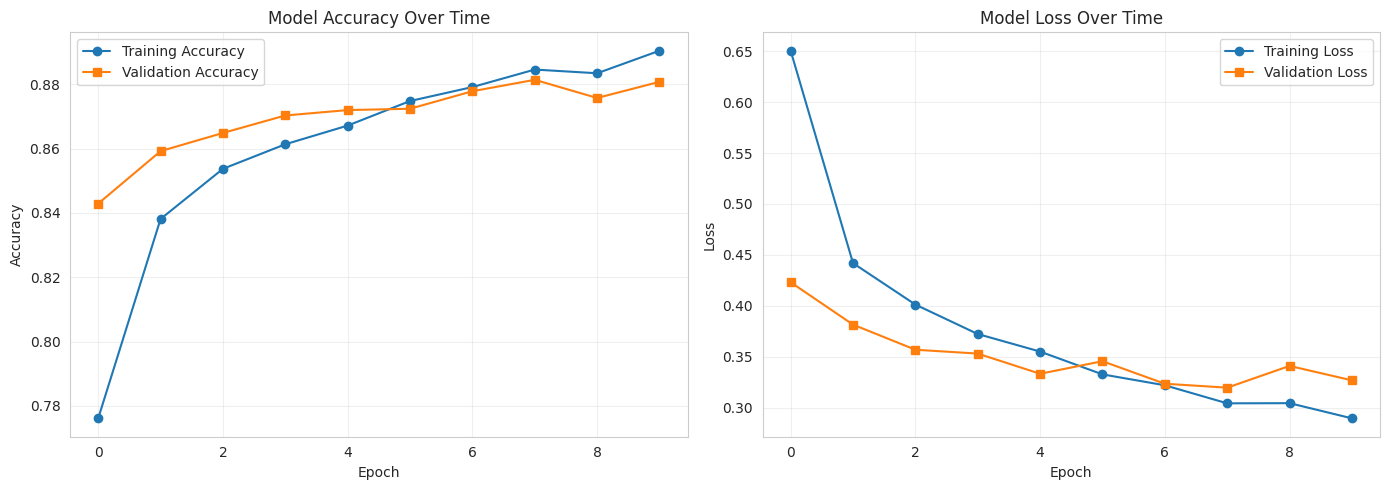

In [43]:
# Plot training & validation accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], marker='o', label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], marker='s', label='Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], marker='o', label='Training Loss')
ax2.plot(history.history['val_loss'], marker='s', label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Model Loss Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### STEP 15: TRAINING A LARGER MODEL

In [44]:
def make_model(input_size=150, learning_rate=0.01, size_inner=100,
               droprate=0.5):

    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(input_size, input_size, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(input_size, input_size, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)

    outputs = keras.layers.Dense(15)(drop)

    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [45]:
input_size = 299

In [46]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_ds = train_gen.flow_from_directory(
    '/content/fashion_dataset/train',
    target_size=(input_size, input_size),
    batch_size=32
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = train_gen.flow_from_directory(
    '/content/fashion_dataset/validation',
    target_size=(input_size, input_size),
    batch_size=32,
    shuffle=False
)

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = test_gen.flow_from_directory(
    '/content/fashion_dataset/test',
    target_size=(input_size, input_size),
    batch_size=32,
    shuffle=False
)

Found 19119 images belonging to 15 classes.
Found 4780 images belonging to 15 classes.
Found 5975 images belonging to 15 classes.


In [47]:
callbacks_list = [
    keras.callbacks.ModelCheckpoint(
        'checkpoints/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.CSVLogger('logs/training_history.csv'),
]

In [48]:
learning_rate = 0.0005
size = 100
droprate = 0.2

model = make_model(
    input_size=input_size,
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=callbacks_list
)

Epoch 1/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 730ms/step - accuracy: 0.7368 - loss: 0.8394
Epoch 1: val_accuracy improved from -inf to 0.88096, saving model to checkpoints/best_model.keras
598/598 ━━━━━━━━━━━━━━━━━━━━ 614s 962ms/step - accuracy: 0.7369 - loss: 0.8389 - val_accuracy: 0.8810 - val_loss: 0.3286 - learning_rate: 5.0000e-04
Epoch 2/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - accuracy: 0.8858 - loss: 0.3227
Epoch 2: val_accuracy improved from 0.88096 to 0.89498, saving model to checkpoints/best_model.keras
598/598 ━━━━━━━━━━━━━━━━━━━━ 563s 941ms/step - accuracy: 0.8858 - loss: 0.3227 - val_accuracy: 0.8950 - val_loss: 0.2939 - learning_rate: 5.0000e-04
Epoch 3/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.8928 - loss: 0.2957
Epoch 3: val_accuracy improved from 0.89498 to 0.89728, saving model to checkpoints/best_model.keras
598/598 ━━━━━━━━━━━━━━━━━━━━ 514s 860ms/step - accuracy: 0.8928 - loss: 0.2956 - val_accuracy: 0.8973 - val_loss: 0.2829 - learning_rate: 

In [52]:
history.history

{'accuracy': [0.8206496238708496,
  0.884878933429718,
  0.8953397274017334,
  0.9059574007987976,
  0.9109262824058533,
  0.9173073768615723,
  0.9166274666786194,
  0.9199225902557373,
  0.9224331974983215,
  0.9239500164985657],
 'loss': [0.5297686457633972,
  0.32262158393859863,
  0.28591418266296387,
  0.26106351613998413,
  0.24472598731517792,
  0.22898812592029572,
  0.22203095257282257,
  0.21171900629997253,
  0.20672836899757385,
  0.19777193665504456],
 'val_accuracy': [0.8809623718261719,
  0.8949790596961975,
  0.8972803354263306,
  0.8972803354263306,
  0.9037656784057617,
  0.9096234440803528,
  0.9014644622802734,
  0.9052301049232483,
  0.9075313806533813,
  0.9108786582946777],
 'val_loss': [0.32857516407966614,
  0.2938615679740906,
  0.28292855620384216,
  0.2715902328491211,
  0.2635513246059418,
  0.2540299892425537,
  0.25326400995254517,
  0.24588194489479065,
  0.24586158990859985,
  0.24090883135795593],
 'learning_rate': [0.0005000000237487257,
  0.00050000

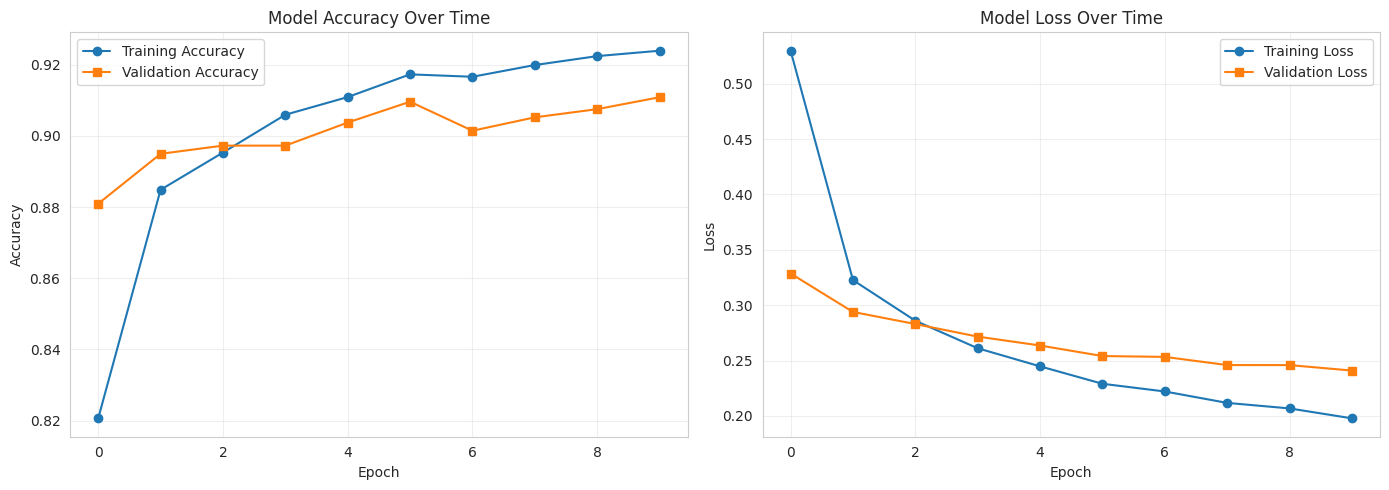

In [49]:
# Plot training & validation accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], marker='o', label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], marker='s', label='Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], marker='o', label='Training Loss')
ax2.plot(history.history['val_loss'], marker='s', label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Model Loss Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### STEP 12: EVALUATE AND ANALYZE

In [50]:
best_model = keras.models.load_model('checkpoints/best_model.keras')
print("\n✅ Loaded best model from checkpoint")


✅ Loaded best model from checkpoint


In [51]:
# Evaluate on test set
print("\n📊 Evaluating on test set...")
test_results = best_model.evaluate(test_ds, verbose=0)

print(f"\n🎯 Test Results:")
print(f"   Loss: {test_results[0]:.4f}")
print(f"   Accuracy: {test_results[1]*100:.2f}%")


📊 Evaluating on test set...

🎯 Test Results:
   Loss: 0.2429
   Accuracy: 91.20%


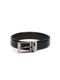

In [60]:
path = '/content/fashion_dataset/train/Belts'
name = '10331.jpg'
fullname = f'{path}/{name}'
load_img(fullname)

In [53]:
# Make predictions
print("\n🔮 Making predictions...")

path = '/content/fashion_dataset/test/Belts/10330.jpg'

img = load_img(path, target_size=(299, 299))

x = np.array(img)
X = np.array([x])
X.shape


🔮 Making predictions...


(1, 299, 299, 3)

In [73]:
X = preprocess_input(X)

In [54]:
pred = best_model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


In [57]:
category_names = [
    'Belts',
    'Briefs',
    'Casual Shoes',
    'Flip Flops',
    'Handbags',
    'Heels',
    'Kurtas',
    'Sandals',
    'Shirts',
    'Sports Shoes',
    'Sunglasses',
    'Tops',
    'Tshirts',
    'Wallets',
    'Watches'
    ]

dict(zip(category_names, pred[0]))

{'Belts': np.float32(8.221444),
 'Briefs': np.float32(-3.0498638),
 'Casual Shoes': np.float32(-0.47646064),
 'Flip Flops': np.float32(-2.926637),
 'Handbags': np.float32(2.4861479),
 'Heels': np.float32(-2.9118414),
 'Kurtas': np.float32(-4.5387626),
 'Sandals': np.float32(-4.3381095),
 'Shirts': np.float32(-2.534445),
 'Sports Shoes': np.float32(-1.3103305),
 'Sunglasses': np.float32(-4.0416145),
 'Tops': np.float32(-5.7299886),
 'Tshirts': np.float32(-3.0988035),
 'Wallets': np.float32(-1.0528392),
 'Watches': np.float32(-0.30545694)}

In [ ]:
# 1. Zip all three folders into a single archive
!zip -r my_data.zip /content/checkpoints /content/fashion_dataset /content/logs

In [59]:
# 2. Trigger the download to your computer
from google.colab import files
files.download("my_data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

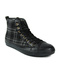

In [66]:
path = '/content/fashion_dataset/test/Casual_Shoes'
name = '10167.jpg'
fullname = f'{path}/{name}'
load_img(fullname)

In [69]:
# Make predictions
print("\n🔮 Making predictions...")

path = '/content/fashion_dataset/test/Casual_Shoes/10167.jpg'

img = load_img(path, target_size=(299, 299))

x = np.array(img)
X = np.array([x])
X.shape


🔮 Making predictions...


(1, 299, 299, 3)

In [70]:
X = preprocess_input(X)

In [71]:
pred = best_model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [72]:
category_names = [
    'Belts',
    'Briefs',
    'Casual Shoes',
    'Flip Flops',
    'Handbags',
    'Heels',
    'Kurtas',
    'Sandals',
    'Shirts',
    'Sports Shoes',
    'Sunglasses',
    'Tops',
    'Tshirts',
    'Wallets',
    'Watches'
    ]

dict(zip(category_names, pred[0]))

{'Belts': np.float32(-5.90054),
 'Briefs': np.float32(-6.9819846),
 'Casual Shoes': np.float32(7.3115544),
 'Flip Flops': np.float32(-2.382624),
 'Handbags': np.float32(-1.8651421),
 'Heels': np.float32(1.8671192),
 'Kurtas': np.float32(-6.1064277),
 'Sandals': np.float32(-0.54019624),
 'Shirts': np.float32(-4.266271),
 'Sports Shoes': np.float32(4.5647507),
 'Sunglasses': np.float32(-6.3900514),
 'Tops': np.float32(-1.8311504),
 'Tshirts': np.float32(-1.8539845),
 'Wallets': np.float32(-1.1682774),
 'Watches': np.float32(-3.9680037)}